In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import classification_report
import pandas as pd
import requests
import re
import numpy as np
import warnings
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


def get_answers(text):
    if re.fullmatch("\d\d?", text):
        matches = re.findall("\d\d?", text)
    elif re.fullmatch("[\d\d?, ]+", text):
        matches = re.findall("\d\d?", text)
    else:
        matches = re.findall("\d\d?", text)[-1:]
    return [int(m) for m in matches if int(m) < 15]



def default_evaluation(true_labels, pred_labels):
    result = dict()
    result['precision'] = precision_score(true_labels, pred_labels)
    result['recall'] = recall_score(true_labels, pred_labels)
    result['f1'] = f1_score(true_labels, pred_labels)
    result['accuracy'] = accuracy_score(true_labels, pred_labels)
    return result


def get_sampled_results(preds, df, report=False, include_pop=False):
    new_df = {"sample_id": [], "questionEntityId":[],"prediction": []}
    if include_pop:
        new_df["popularity"] = []

    for _, row in preds.iterrows():
        for _, id in row['match_dict'].items():
            new_df["sample_id"].append(id)
            new_df["prediction"].append(id in row['prediction_sample_id'])
            new_df["questionEntityId"].append(row['questionEntityId'])
            if include_pop:
                # print(type(row["popularity"]))
                new_df["popularity"].append(row["popularity"][0] if type(row["popularity"]) == list else row["popularity"])

    result = pd.DataFrame(data=new_df)
    result = result.sort_values(by=["sample_id"]).reset_index(drop=True)
    result.prediction = result.prediction.astype(np.int32)
    all_sample_ids = set(result["sample_id"].values.tolist())
    df = df[df.sample_id.apply(lambda x: x in all_sample_ids)].sort_values(by=["sample_id"])
    result["correct"] = df['correct'].astype(np.int32).values
    # if include_pop:
        # result["popularity"] = result.sample_id.apply(lambda x: sample2pop(df, x))
    
    if report:
        true_labels = df['correct'].astype(np.int32).values
        pred_labels = result['prediction'].astype(np.int32).values
        print(classification_report(pred_labels, true_labels))
        metrics = default_evaluation(true_labels, pred_labels)
        print(metrics)
        return result, metrics
    
    return result


key = ''
def wikimedia_pagereviews(label, start_data="20230101", end_date="20230901"):
    label = label[0].upper() + label[1:]
    if '/' in label:
        test_lbl = label.replace('/', '%2F')
    elif '?' in label:
        test_lbl = label.replace('?', '%3F')
    else:
        test_lbl = '_'.join(label.split(' '))
        
    url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/"
    url += f"{test_lbl}/monthly/{start_data}/{end_date}"
    headers = {
        'accept': 'application/json',
        'Authorization': key,
        'User-Agent': '2368ba8df0e5f6b69af8027312c507c654c234c8'
    }

    response = requests.get(
        url = url,
        headers=headers,
    )   
    print(url)
    
    return response.json()['items'][0]['views']

def sample2wiki_id(df, sample_id):
    sample_id = int(sample_id)
    return df[df['sample_id'] == sample_id]['answerEntityId'].values[0]

def sample2wiki(df, sample_id):
    sample_id = int(sample_id)
    return df[df['sample_id'] == sample_id]['answerEntity'].values[0]

def sample2pop(df, sample_id):
    sample_id = int(sample_id)
    answer_id = sample2wiki_id(df, sample_id)
    pop = views[views['answerEntityId'] == answer_id]['views'].values
    return pop[0] if len(pop) > 0 else -1

def index2sample(match_dict, idx):
    return match_dict[idx]




def popularity(df, raw):
    res = []
    for token in raw['top_token']:
        try:
            sample_id = index2sample(raw['match_dict'], token)
        except:
            continue
        try:
            wiki_id = sample2wiki_id(df, sample_id)
            val = views[views['answerEntityId'] == wiki_id]['views'].values
        except:
            wiki = sample2wiki(df, sample_id)
            val = views[views['answerEntity'] == wiki]['views'].values
        if val:
            res.append(val[0])
    return sum(res) / len(res) if res else -1


def init_preds(preds, multi=False, first=False):
    preds['prediction'][preds['prediction'].isna()] = "None"
    preds['raw_prediction'] = preds["prediction"]
    preds['match_dict'] = preds['match_dict'].apply(eval)
    preds['top_token'] = preds['raw_prediction'].apply(get_answers)
    preds['popularity'] = [popularity(df, row) for i, row in preds.iterrows()]
    preds['popularity'] = [popularity(df, row) for i, row in preds.iterrows()]
    preds['prediction_sample_id'] = preds.apply(lambda row: [index2sample(row["match_dict"], int(token)) for token in row["top_token"] if int(token) in row["match_dict"]], axis=1)

In [2]:
train_file_path = "../TextGraphs17-shared-task/data/tsv/train.tsv"
file_ws = '../analysis/llama_8B_train_sample_ds_ws_probs.tsv'
file_ds = '../analysis/llama_8B_train_sample_ds_probs.tsv'

df = pd.read_csv(train_file_path, sep="\t")
views = pd.read_csv("views.csv")

df_ws = pd.read_csv(file_ws, sep='\t')
init_preds(df_ws)

df_ds = pd.read_csv(file_ds, sep='\t')
init_preds(df_ds)

In [25]:
an_dir = "../analysis/"
all_files = os.listdir(an_dir)
data = {}

for file in all_files:
    print(f"Loading {file}")
    name = file.split(".")[0]
    filepath = os.path.join(an_dir, file)
    df_ = pd.read_csv(filepath, sep='\t')
    init_preds(df_)
    data[name] = df_

Loading llama_70B_train_sample_ds_probs.tsv
Loading llama_70B_train_sample_ds_tg_probs.tsv
Loading llama_70B_train_sample_ds_tg_ws_probs.tsv
Loading llama_70B_train_sample_ds_ws_probs.tsv
Loading llama_8B_train_sample_ds_probs.tsv
Loading llama_8B_train_sample_ds_tg_probs.tsv
Loading llama_8B_train_sample_ds_tg_ws_probs.tsv
Loading llama_8B_train_sample_ds_ws_probs.tsv


In [102]:
top_questions = 100

predictions = {}

for name, df_ in data.items():
    df_preds = get_sampled_results(df_, df, report=False, include_pop=True)
    predictions[name] = df_preds
    df_preds = df_preds[df_preds.popularity != -1].sort_values("popularity", ascending=False).reset_index(drop=True)
    print(f"-----------{name} top {top_questions}----------------")
    df_slice = df_preds.groupby("questionEntityId").head(top_questions)
    metrics = default_evaluation(df_slice["prediction"], df_slice["correct"])
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print(f"-----------{name} tail {top_questions}----------------")
    df_slice = df_preds.groupby("questionEntityId").tail(top_questions)
    metrics = default_evaluation(df_slice["prediction"], df_slice["correct"])
    for k, v in metrics.items():
        print(f"{k}: {v}")
    print("\n\n")

-----------llama_70B_train_sample_ds_probs top 100----------------
precision: 0.7320197044334975
recall: 0.7573904179408767
f1: 0.7444889779559118
accuracy: 0.9507912003087611
-----------llama_70B_train_sample_ds_probs tail 100----------------
precision: 0.7285291214215203
recall: 0.7553735926305015
f1: 0.7417085427135678
accuracy: 0.9504052489386338



-----------llama_70B_train_sample_ds_tg_probs top 100----------------
precision: 0.7181008902077152
recall: 0.7476828012358393
f1: 0.7325933400605449
accuracy: 0.9487080228394464
-----------llama_70B_train_sample_ds_tg_probs tail 100----------------
precision: 0.7168316831683168
recall: 0.7479338842975206
f1: 0.7320525783619818
accuracy: 0.9487080228394464



-----------llama_70B_train_sample_ds_tg_ws_probs top 100----------------
precision: 0.7507447864945382
recall: 0.7769784172661871
f1: 0.7636363636363637
accuracy: 0.9545719277810134
-----------llama_70B_train_sample_ds_tg_ws_probs tail 100----------------
precision: 0.7495049504950

In [99]:
ds_name = 'llama_8B_train_sample_ds_probs'
ws_name = 'llama_8B_train_sample_ds_ws_probs'

ds_predictions = predictions[ds_name]
ws_predictions = predictions[ws_name]

df_new = pd.DataFrame(
    {
        "ds_prediction": ds_predictions["prediction"],
        "ds_popularity": ds_predictions["popularity"],
        "ws_prediction": ws_predictions["prediction"],
        "ws_popularity": ws_predictions["popularity"],
        "correct": ds_predictions["correct"]
    }
)

df_new["final_prediction"] = df_new.apply(lambda row: row["ds_prediction"] if row["ds_popularity"] > row["ws_popularity"] else row["ws_prediction"], axis=1)

In [100]:
default_evaluation(df_new["correct"], df_new["final_prediction"])

{'precision': np.float64(0.536),
 'recall': np.float64(0.5090218423551757),
 'f1': np.float64(0.5221626887481734),
 'accuracy': 0.9089643652561247}

In [93]:
default_evaluation(df_new["correct"], df_new["ds_prediction"])

{'precision': np.float64(0.46046046046046046),
 'recall': np.float64(0.4368471035137702),
 'f1': np.float64(0.44834307992202727),
 'accuracy': 0.8949517446176689}

In [94]:
default_evaluation(df_new["correct"], df_new["ws_prediction"])

{'precision': np.float64(0.5923309788092835),
 'recall': np.float64(0.5574548907882241),
 'f1': np.float64(0.5743639921722113),
 'accuracy': 0.9192650334075724}

In [123]:
df_ds_false = df_new[(df_new.ds_prediction != df_new.correct) & (df_new.ws_prediction == df_new.correct)]
df_ds_true = df_new[(df_new.ds_prediction == df_new.correct) & (df_new.ws_prediction != df_new.correct)]

<Axes: >

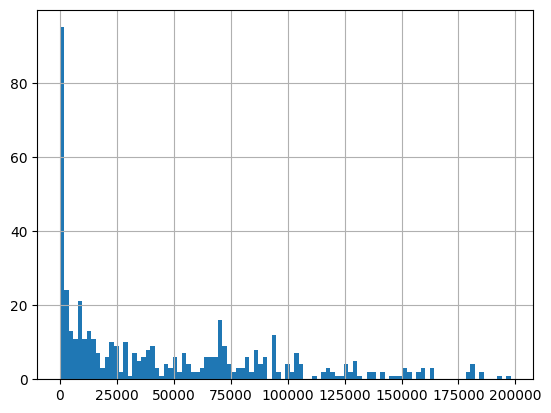

In [130]:
df_ds_false[df_ds_false.ds_popularity < 0.2e6].ds_popularity.hist(bins=100)

<Axes: >

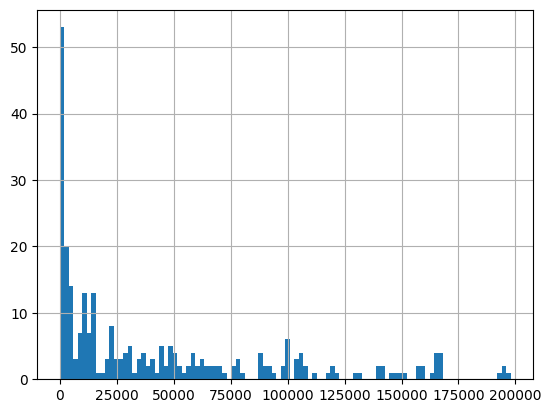

In [129]:
df_ds_true[df_ds_true.ds_popularity < 0.2e6].ds_popularity.hist(bins=100)

In [133]:
views.sort_values("views").head(20)

,Unnamed: 0,answerEntityId,answerEntity,views
518,518,Q18086665,Hoenn Pokédex,1
5356,5356,Q13569737,Their Second Album! Herman's Hermits on Tour,1
1742,1742,Q23643186,War of 1812 Shipwrecks,1
5090,5090,Q75310902,Katharine Seymour,1
3909,3909,Q97738250,presidential inauguration of Joe Biden,1
4354,4354,Q274400,88 Minutes,1
5061,5061,Q59156341,Birds of a Feather...,1
259,259,Q18611720,Innocence + Experience Tour,1
2959,2959,Q3565721,Walter Creighton Brown,1
2863,2863,Q7798571,Thru the Looking Glass,1


# Scrap views

In [3]:
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from retrying import retry

# Функция для получения данных из Wikimedia с повторной попыткой
@retry(stop_max_attempt_number=5, wait_fixed=2000)
def fetch_data_with_retry(label, start_date="20230101", end_date="20230901"):
    return wikimedia_pagereviews(label, start_date, end_date)

# Основная функция для получения данных из Wikimedia
def wikimedia_pagereviews(label, start_date="20230101", end_date="20230901"):
    label = label[0].upper() + label[1:]
    if '/' in label:
        test_lbl = label.replace('/', '%2F')
    elif '?' in label:
        test_lbl = label.replace('?', '%3F')
    else:
        test_lbl = '_'.join(label.split(' '))
        
    url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/"
    url += f"{test_lbl}/monthly/{start_date}/{end_date}"
    headers = {
        'accept': 'application/json',
        'Authorization': 'key',  # Замените 'key' на ваш ключ API, если требуется
        'User-Agent': '2368ba8df0e5f6b69af8027312c507c654c234c8'
    }

    response = requests.get(url=url, headers=headers)
    
    if response.status_code != 200:
        response.raise_for_status()  # Для повторной попытки в случае ошибки

    # print(url)
    items = response.json()['items']
    return [items[i]['views'] for i in range(len(items))]

# Обертка для функции с обработкой исключений
def safe_wikimedia_pagereviews(label, start_date="20230101", end_date="20230901"):
    try:
        return fetch_data_with_retry(label, start_date, end_date)
    except Exception as exc:
        print(f"Error fetching data for {label}: {exc}")
        return -1

# Параллельный скраппер
def parallel_scraper(labels, start_date="20230101", end_date="20230901", max_workers=8):
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_label = {executor.submit(safe_wikimedia_pagereviews, label, start_date, end_date): label for label in labels}
        with tqdm(total=len(labels)) as pbar:
            for future in as_completed(future_to_label):
                label = future_to_label[future]
                try:
                    data = future.result()
                    results.append((label, data))
                except Exception as exc:
                    print(f"{label} generated an exception: {exc}")
                    results.append((label, -1))
                pbar.update(1)
    return results

In [4]:
all_answers = set()
all_answer_ids = set()

for match_dict in df_ws["match_dict"]:
    for sample_id in match_dict.values():
        all_answers.add(sample2wiki(sample_id=sample_id, df=df))
        all_answer_ids.add(sample2wiki_id(df=df, sample_id=sample_id))

In [5]:
results = parallel_scraper(all_answers)

Error fetching data for Dwight Eisenhower Seated at Official Function: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/Dwight_Eisenhower_Seated_at_Official_Function/monthly/20230101/20230901
Error fetching data for Zdanevich: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/Zdanevich/monthly/20230101/20230901
Error fetching data for St. Johns College of Pharmaceutical Sciences and Research: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-access/all-agents/St._Johns_College_of_Pharmaceutical_Sciences_and_Research/monthly/20230101/20230901
Error fetching data for Warren E. Burger and the Administration of Justice: 404 Client Error: Not Found for url: https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia.org/all-a